In [1]:
import numpy as np
import scipy.stats as ss
import scipy as sp
import matplotlib.pyplot as plt 

In [2]:
def LCG(a,c, M, N, x0):
    
    arr = np.empty(N, dtype=np.float64)
    arr[0] = x0 % M

    # Loop
    for i in range(1,N):
        arr[i] = (a*arr[i-1] + c) % M
    
    return arr

In [3]:
M = 16
Values = LCG(5,1,M,10_000,3)/M
Values

array([0.1875, 0.    , 0.0625, ..., 0.25  , 0.3125, 0.625 ],
      shape=(10000,))

(array([625., 625., 625., 625., 625., 625., 625., 625., 625., 625., 625.,
        625., 625., 625., 625., 625.]),
 array([0.        , 0.05859375, 0.1171875 , 0.17578125, 0.234375  ,
        0.29296875, 0.3515625 , 0.41015625, 0.46875   , 0.52734375,
        0.5859375 , 0.64453125, 0.703125  , 0.76171875, 0.8203125 ,
        0.87890625, 0.9375    ]),
 <BarContainer object of 16 artists>)

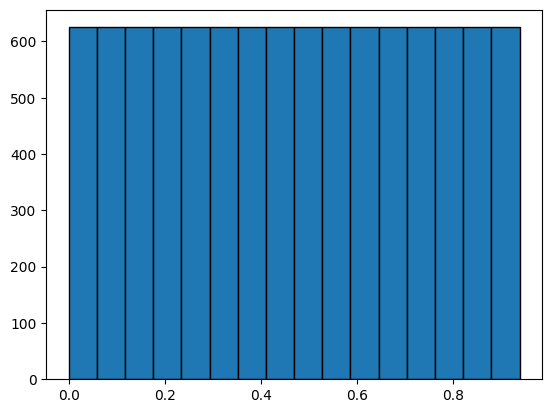

In [4]:
#plot.plot(Values)

plt.hist(Values, bins=16,edgecolor = "black")

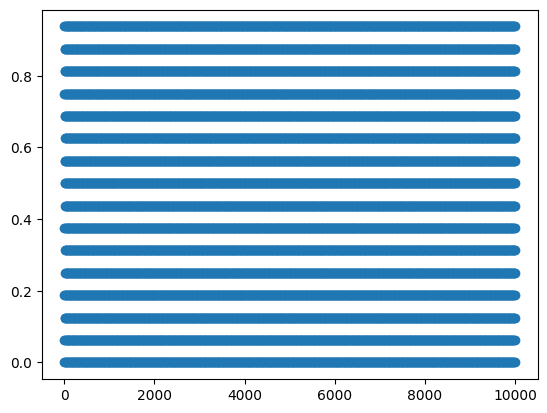

In [5]:
plt.scatter(np.arange(len(Values)),Values)

In [6]:
data = Values
F = lambda x: np.clip(x, 0, 1)  # uniform fordeling 

def smirnov(data, CDF):
    data_sorted = np.sort(data)
    p = np.arange(len(data_sorted)) / (len(data_sorted) - 1)   # empirical CDF
    p_cdf = CDF(data_sorted)                      # theoretical CDF
    D = np.max(np.abs(p - p_cdf))                 # sup
    return D

In [7]:
a = [129, 5, 1103515245, 1664525]
c = [26461, 1, 12345, 1013904223]
M = [64499, 16, 2**31, 2**32]
N = [10_000, 10_000, 10_000, 10_000]
x0 = [30,30,30,30]

In [8]:
for i in range(4):
    array = LCG(a[i],c[i],M[i],N[0],x0[0])/M[i]
    print(smirnov(array,F))

0.008830252472835642
0.0625
0.006693007767420989
0.01615895061475292


In [9]:
smirnov(data,F)

np.float64(0.0625)

# 2


In [ ]:
np.random.seed(30)
data= np.random.uniform(low= 0, high=1,size=10_000)


np.float64(0.007984710126879624)

In [23]:
def run_test_1(x):
    m = np.median(x)
    n1 = np.sum(x > m)
    n2 = np.sum(x <= m)

    mu_T = 2 * n1*n2 / (n1+n2) + 1 # Mean, or Expected number of runs
    sig_T = np.sqrt(2 * n1*n2 * (2*n1*n2-n1-n2) / ((n1+n2)**2 * (n1+n2-1))) # Variance

    s = (x > m) # Number of runs above the median

    T = 1 + np.sum(s[1:] != s[:-1]) # Compare adjacent elements to obtain T
    print('Total number of runs: T =', T)

    Z = (T - mu_T) / sig_T # Measure how far we are from what we expect
    print('Comparison with the theory: Z =', Z)
    p =  2*(1 - ss.norm.cdf(abs(Z)))
    return p    

In [25]:
run_test_1(data)

Total number of runs: T = 4912
Comparison with the theory: Z = -1.7800890155777815


np.float64(0.0750613939575997)

In [19]:
p = 2 * (1 - ss.norm.cdf(abs(Z)))
p

np.float64(0.0750613939575997)

In [30]:

data = LCG(a[0],c[0],M[0],N[0],x0[0])/M[0]
#print(smirnov(data,F))
print(run_test_1(data))

Total number of runs: T = 4958
Comparison with the theory: Z = -0.8600430075263439
0.3897653356239932
